In [2]:
%pip install xgboost


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /anaconda/envs/azureml_py310_sdkv2/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report , confusion_matrix, ConfusionMatrixDisplay

In [4]:
ml_client = MLClient.from_config(credential=DefaultAzureCredential())
data_asset = ml_client.data.get("transaction-train", version="1")

train_df = pd.read_csv(data_asset.path)
train_df.head()

Found the config file in: /config.json
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/azureml/dataprep/api/_loggerfactory.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets

,is_fraud,account_type,transaction_type,transaction_amount,transaction_direction,merchant_category,state,credit_score,loan_type,emi_amount,channel,kyc_status,transaction_hour,transaction_minute,prior_transaction_count,amount_to_average_ratio
0,0,Savings,POS,5098.14,Debit,Food & Dining,Tamil Nadu,407,NaN,0.00,Web,Verified,0,23,3,0.52
1,0,Current,RTGS,278744.72,Debit,Utilities,UP,846,NaN,0.00,ATM,Verified,20,38,4,82.28
2,0,Savings,UPI,2734.57,Credit,Travel,Delhi,597,NaN,0.00,API,Verified,17,45,3,2.25
3,0,Current,NEFT,43184.26,Credit,Salary,Rajasthan,570,Personal,5084.36,Mobile_App,Verified,18,32,4,2.25
4,0,Savings,Net_Banking,10185.66,Credit,Salary,Gujarat,835,NaN,0.00,ATM,Verified,5,8,7,0.30


In [5]:
ml_client = MLClient.from_config(credential=DefaultAzureCredential())
data_asset = ml_client.data.get("transaction-test", version="1")

test_df = pd.read_csv(data_asset.path)
test_df.head()

Found the config file in: /config.json
Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


,is_fraud,account_type,transaction_type,transaction_amount,transaction_direction,merchant_category,state,credit_score,loan_type,emi_amount,channel,kyc_status,transaction_hour,transaction_minute,prior_transaction_count,amount_to_average_ratio
0,0,Current,ATM_Withdrawal,1000.00,Debit,Food & Dining,Rajasthan,480,NaN,0.00,Mobile_App,Verified,7,4,0,1.00
1,0,Savings,UPI,233.14,Credit,Salary,Maharashtra,616,NaN,0.00,Web,Verified,19,16,8,0.07
2,0,Current,POS,1739.20,Debit,Retail,Maharashtra,527,NaN,0.00,Mobile_App,Verified,15,34,0,1.00
3,0,NRI,RTGS,212734.26,Credit,Entertainment,Rajasthan,779,Unknown,2137.89,Web,Verified,9,54,8,24.03
4,0,Savings,UPI,1529.61,Credit,Real Estate,Tamil Nadu,844,NaN,0.00,Mobile_App,Verified,20,49,3,0.10


In [7]:
onhot_features = ['account_type', 'transaction_direction', 'kyc_status', 'channel']
freq_features = ['transaction_type', 'merchant_category', 'state', 'loan_type']
skew_features = ['transaction_amount', 'emi_amount']
norm_features = ['credit_score', 'transaction_hour', 'transaction_minute']

In [8]:
X = train_df.drop(columns=['is_fraud'])
y = train_df['is_fraud']

test_X = test_df.drop(columns=['is_fraud'])
test_y = test_df['is_fraud']

In [9]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        # scikit-learn convention: all init args must be stored as attributes
        self.columns = columns
        self.freq_maps = {}

    def fit(self, X, y=None):
        """
        Fit the encoder by calculating frequency of values in given columns.
        """
        if self.columns is None:
            self.columns = X.select_dtypes(include=['object', 'category']).columns.tolist()
        
        for col in self.columns:
            freq_map = X[col].value_counts(normalize=True).to_dict()
            self.freq_maps[col] = freq_map
        return self

    def transform(self, X):
        """
        Transform the dataframe using the fitted frequency maps.
        """
        X_transformed = X.copy()
        for col in self.columns:
            X_transformed[col] = X_transformed[col].map(self.freq_maps[col])
        return X_transformed


In [35]:
# Preprocessing: different transformers for different sets of columns
preprocessor = ColumnTransformer(
    transformers=[
        ('onhot', OneHotEncoder(handle_unknown='ignore'), onhot_features),
        ('frequency', FrequencyEncoder(),freq_features),
        ('num', StandardScaler(), norm_features),
        ('log', FunctionTransformer(np.log1p, validate=True), skew_features)
    ]
)

# Full pipeline: preprocessing + model
pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('impute', SimpleImputer(strategy='mean')),
    ("smote", SMOTE(sampling_strategy=.9,random_state=42)),
    ('model', LogisticRegression())
])

# Fit the pipeline
pipeline.fit(X, y)

# Evaluate
print("Train score:", pipeline.score(X, y))
print("Test score:", pipeline.score(test_X, test_y))


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train score: 0.7110382104888584
Test score: 0.7108883528684501


              precision    recall  f1-score   support

           0       0.99      0.71      0.83     81770
           1       0.01      0.35      0.02       731

    accuracy                           0.71     82501
   macro avg       0.50      0.53      0.43     82501
weighted avg       0.98      0.71      0.82     82501



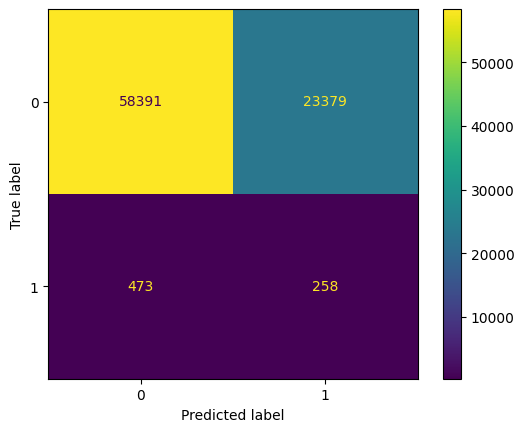

In [36]:
pred_y = pipeline.predict(test_X)
report = classification_report(test_y, pred_y)
print(report)

con_mat = confusion_matrix(test_y, pred_y)
ConfusionMatrixDisplay(con_mat).plot()

              precision    recall  f1-score   support

           0       0.99      0.87      0.93     81770
           1       0.01      0.20      0.03       731

    accuracy                           0.87     82501
   macro avg       0.50      0.54      0.48     82501
weighted avg       0.98      0.87      0.92     82501



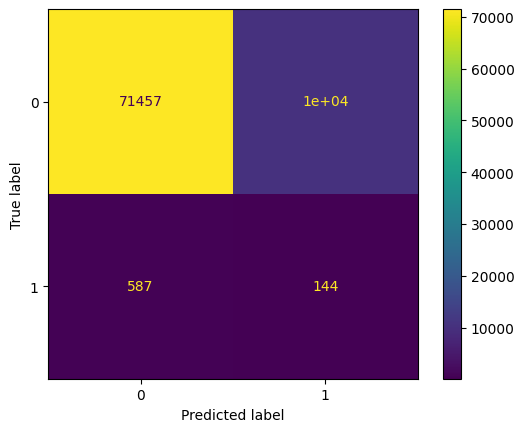

In [25]:
pred_y = pipeline.predict(test_X)
report = classification_report(test_y, pred_y)
print(report)

con_mat = confusion_matrix(test_y, pred_y)
ConfusionMatrixDisplay(con_mat).plot()

In [10]:
params = {
        "bootstrap": False,
        "class_weight": "balanced",
        "criterion": "gini",
        "max_features": "sqrt",
        "min_samples_leaf": 0.01,
        "min_samples_split": 0.38473684210526315,
        "n_estimators": 100,
        "oob_score": False}

preprocessor = ColumnTransformer(
    transformers=[
        ('onhot', OneHotEncoder(handle_unknown='ignore'), onhot_features),
        ('frequency', FrequencyEncoder(),freq_features),
        ('num', StandardScaler(), norm_features),
        ('log', FunctionTransformer(np.log1p, validate=True), skew_features)
    ]
)

# Full pipeline: preprocessing + model
pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('impute', SimpleImputer(strategy='mean')),
    ('model', RandomForestClassifier(**params))
])

# Fit the pipeline
pipeline.fit(X, y)

# Evaluate
print("Train score:", pipeline.score(X, y))
print("Test score:", pipeline.score(test_X, test_y))

Train score: 0.8328670983560996
Test score: 0.8350201815735567


              precision    recall  f1-score   support

           0       0.99      0.84      0.91     81770
           1       0.01      0.24      0.03       731

    accuracy                           0.84     82501
   macro avg       0.50      0.54      0.47     82501
weighted avg       0.98      0.84      0.90     82501



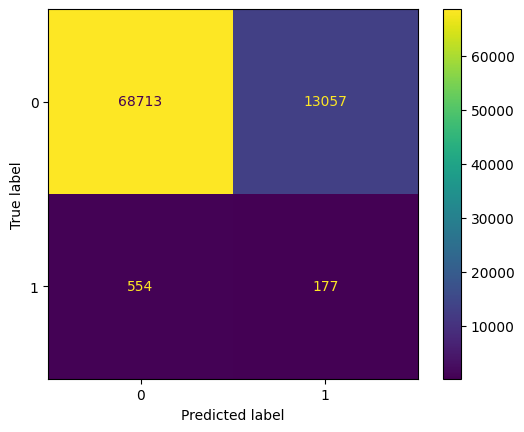

In [13]:
pred_rf_y = pipeline.predict(test_X)
report = classification_report(test_y, pred_rf_y)
print(report)

con_mat = confusion_matrix(test_y, pred_rf_y)
ConfusionMatrixDisplay(con_mat).plot()

In [14]:
from azure.ai.ml import MLClient, automl, Input
from azure.identity import DefaultAzureCredential

# Registered Azure ML data asset
TRAIN_DATA = (
    "azureml:transaction-train-data:1"
)
VALIDATION_DATA = (
    "azureml:transaction-val-data:1"
)
TEST_DATA = (
    "azureml:transaction-test-data:1"
)
TARGET_COLUMN = "is_fraud"

ml_client =ml_client = MLClient.from_config(credential=DefaultAzureCredential())

# Create the AutoML classification job
fraud_detection_job = automl.classification(
    training_data=Input(
        type="mltable",
        path=TRAIN_DATA,
    ),
    validation_data = Input(
        type="mltable",
        path=VALIDATION_DATA,
    )
    test_data = Input(
        type="mltable",
        path=TEST_DATA,
    )
    target_column_name=TARGET_COLUMN,
    primary_metric="norm_macro_recall",
    experiment_name="fraud-detection-automl",
    compute="durrain20031",
    n_cross_validations=5,
    timeout_minutes=30,
    enable_model_explainability=True,
    tags={
        "project": "fraud-detection",
        "primary_metric": "norm_macro_recall",
    },
)
fraud_detection_job.set_limits(
    max_trials=7,
    max_concurrent_trials=2,
)

# Submit the job
returned_job = ml_client.jobs.create_or_update(fraud_detection_job)

print(f"Submitted job: {returned_job.name}")

# Wait for completion
ml_client.jobs.stream(returned_job.name)

completed_job = ml_client.jobs.get(
    returned_job.name
)

print(f"Job status: {completed_job.status}")

'hi'

In [ ]:
'hello'